# Pertemuan 4 - Statistika Dasar

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Statistika deskriptif dan eksplorasi dataset Iris.


## 1. Load Dataset Iris


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
    "target": "species"
})
df["species"] = df["species"].map(dict(enumerate(iris.target_names)))

display(df.head())
display(df.describe().round(3))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## 2. Statistik Deskriptif Lengkap


In [2]:
for col in df.select_dtypes(include="number").columns:
    print(f"\n=== {col} ===")
    print("Mean:", round(df[col].mean(), 3))
    print("Median:", round(df[col].median(), 3))
    print("Std:", round(df[col].std(), 3))
    print("Variance:", round(df[col].var(), 3))
    print("Skewness:", round(df[col].skew(), 3))
    print("Kurtosis:", round(df[col].kurt(), 3))



=== sepal_length ===
Mean: 5.843
Median: 5.8
Std: 0.828
Variance: 0.686
Skewness: 0.315
Kurtosis: -0.552

=== sepal_width ===
Mean: 3.057
Median: 3.0
Std: 0.436
Variance: 0.19
Skewness: 0.319
Kurtosis: 0.228

=== petal_length ===
Mean: 3.758
Median: 4.35
Std: 1.765
Variance: 3.116
Skewness: -0.275
Kurtosis: -1.402

=== petal_width ===
Mean: 1.199
Median: 1.3
Std: 0.762
Variance: 0.581
Skewness: -0.103
Kurtosis: -1.341


## 3. Visualisasi Distribusi dan Korelasi


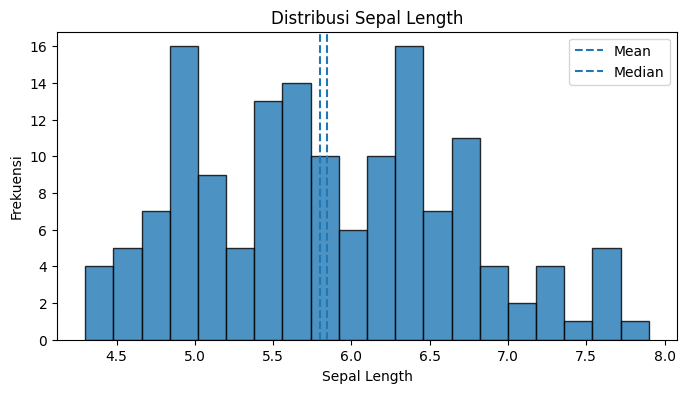

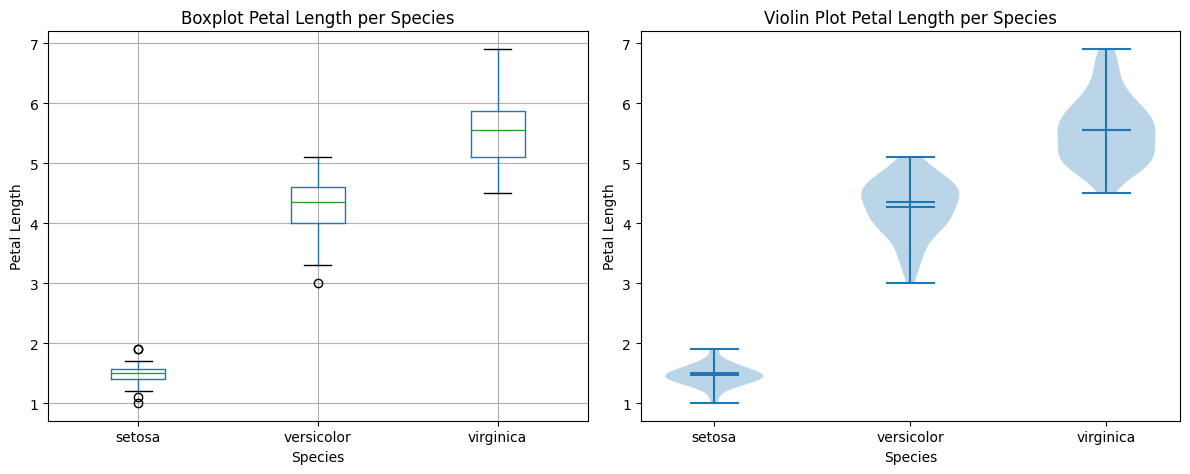

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


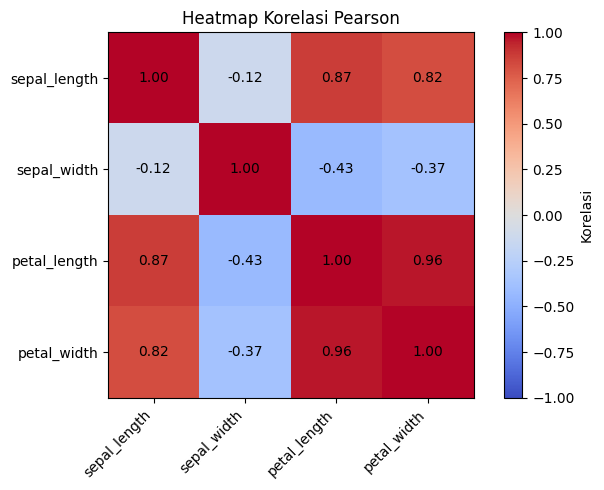

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df["sepal_length"], bins=20, alpha=0.8, edgecolor="black")
plt.axvline(df["sepal_length"].mean(), linestyle="--", label="Mean")
plt.axvline(df["sepal_length"].median(), linestyle="--", label="Median")
plt.legend()
plt.title("Distribusi Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frekuensi")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Boxplot dengan pandas/matplotlib
df.boxplot(column="petal_length", by="species", ax=axes[0])
axes[0].set_title("Boxplot Petal Length per Species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Petal Length")

# Violin plot manual matplotlib
groups = [g["petal_length"].values for _, g in df.groupby("species")]
axes[1].violinplot(groups, showmeans=True, showmedians=True)
axes[1].set_xticks(range(1, len(df["species"].unique()) + 1))
axes[1].set_xticklabels(sorted(df["species"].unique()))
axes[1].set_title("Violin Plot Petal Length per Species")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Petal Length")

plt.suptitle("")
plt.tight_layout()
plt.show()

corr = df.drop("species", axis=1).corr()
display(corr.round(3))

plt.figure(figsize=(7, 5))
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Korelasi")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Heatmap Korelasi Pearson")
plt.tight_layout()
plt.show()

## Kesimpulan

Saya mempelajari statistik deskriptif, distribusi, dan korelasi. Temuan utama adalah petal_length dan petal_width memiliki korelasi paling kuat. Keterbatasannya, analisis masih eksploratif dan belum digunakan untuk membuat model.
